In [2]:
import sys
sys.path.append('../')
from datetime import datetime
import pytz, os
import numpy as np
import scipy as sp
from tqdm import tqdm
import scqubits as scq
import scqubits.settings as settings
import qutip as qt
from multiprocessing import Pool
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import utils_2Q_gate_zp as ut
# Update scqubits settings
settings.OVERLAP_THRESHOLD = 0.3
max_step, nsteps = 1e-3, 1e4

In [3]:
drive_phi, drive_theta, truc = False, True, 150
# drive_phi, drive_theta, truc = True, False, 300
folder = '../../data/3ncut_one_zeropi/'
evals = scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta = scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi = scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
evals = evals - evals[0]

In [4]:
dim = 10
qt.Qobj(np.round(n_theta[:dim, :dim], 8))

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[ 0.          1.30441556  0.          0.          0.         -0.01492543
   0.         -0.0522436   0.          0.        ]
 [ 1.30441556  0.         -0.0365515   0.         -1.77718937  0.
   0.          0.         -0.1257867   0.        ]
 [ 0.         -0.0365515   0.          0.          0.         -1.26186733
   0.          0.1908349   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
  -1.28830225  0.          0.          0.        ]
 [ 0.         -1.77718937  0.          0.          0.          0.42924184
   0.          1.99635608  0.          0.        ]
 [-0.01492543  0.         -1.26186733  0.          0.42924184  0.
   0.          0.         -1.39569662  0.        ]
 [ 0.          0.          0.         -1.28830225  0.          0.
   0.          0.          0.          1.72516731]
 [-0.0522436   0.          0.1908349   0.          1.99635608  

In [5]:
hspace_ntheta = [
0,   1,   2,   4,   5,   7,   8,  11,  12,  16,  17,  18,  21,
23,  25,  27,  30,  31,  32,  33,  37,  38,  40,  41,  42,  45,
46,  47,  48,  51,  52,  56,  59,  62,  63,  64,  65,  67,  72,
73,  74,  76,  78,  79,  82,  83,  85,  87,  88,  90,  92,  93,
96,  97,  98, 102, 103, 106, 107, 112, 114, 118, 119, 120, 121,
122, 123, 124, 127, 128, 131, 132, 133, 134, 137, 138, 142, 143
]
hspace_nphi = [
0,   2,   3,   4,   8,   9,  10,  11,  15,  16,  18,  19,  20,
23,  24,  25,  28,  31,  33,  35,  37,  39,  40,  42,  43,  46,
47,  49,  51,  53,  55,  56,  57,  60,  62,  64,  66,  67,  69,
70,  73,  76,  77,  79,  81,  83,  85,  86,  88,  91,  92,  95,
96,  98, 100, 101, 102, 104, 106, 108, 110, 112, 113, 116, 118,
120, 121, 123, 126, 128, 130, 132, 133, 136, 137, 139, 141, 143,
145, 146, 148, 151, 153, 154, 156, 158, 159, 162, 164, 166, 167,
169, 170, 173, 174, 176, 179, 181, 183, 185, 186, 188, 190, 192,
194, 196, 198, 200, 202, 205, 206, 208, 209, 212, 213, 216, 218,
220, 222, 223, 226, 227, 229, 230, 232, 234, 237, 239, 241, 242,
245, 246, 248, 250, 252, 253, 255, 257, 259, 262, 264, 265, 267,
269, 271, 273, 275, 277, 279, 281, 282, 283, 286, 288, 290, 291,
293, 294, 297, 299
]
hspace = hspace_ntheta if drive_theta else hspace_nphi
state_mid = 7 if drive_theta else 9
idx_2 = hspace.index(2)
idx_mid = hspace.index(state_mid)
hspace_len = len(hspace)

# tphi_logi = 100 # μs
t1_other = 50 # μs
# gamma_decay_logi =  1 / 1600e3
# gamma_dephase_logi = 1 / 1e3 / tphi_logi
gamma_decay_other =  1 / 1e3 / t1_other
gamma_dephase_other = 1 / 1e3 / t1_other

# if drive_theta:
#     gamma_decay   = [0, gamma_decay_other,  gamma_decay_logi]  + [gamma_decay_other]  * (hspace_len-3)
#     gamma_dephase = [0, gamma_dephase_other, gamma_dephase_logi] + [gamma_dephase_other] * (hspace_len-3)
# else:
#     gamma_decay   = [0,  gamma_decay_logi]  + [gamma_decay_other]  * (hspace_len-2)
#     gamma_dephase = [0,  gamma_dephase_logi] + [gamma_dephase_other] * (hspace_len-2)

### $T_1$

$\gamma_{ll'} = \Gamma | \bra{l} n_\theta \ket{l'} |^2 = 1/ T_1  $ ( $T_1$ is intrawell decay time )

$\gamma_{07} = \Gamma_{07} | \bra{0} n_\theta \ket{7} |^2 = 1 / (2\times 10^{-6})   $

In [6]:
gamma_decay_0 = []
gamma_decay_2 = []
if drive_theta:
    Gamma_0 = gamma_decay_other / (n_theta[4,7]**2)
    Gamma_2 = gamma_decay_other / (n_theta[2,7]**2)
    for i in hspace:
        gamma_decay_0.append(Gamma_0* n_theta[0, i]**2)
        gamma_decay_2.append(Gamma_2* n_theta[0, i]**2)
else:
    Gamma_0 = gamma_decay_other / (n_phi[0,9]**2)
    Gamma_2 = gamma_decay_other / (n_phi[2,9]**2)
    for i in hspace:
        gamma_decay_0.append(Gamma_0* n_phi[0, i]**2)
        gamma_decay_2.append(Gamma_2* n_phi[0, i]**2)

print('np.imag(gamma_decay_0)=0 -->', np.all(np.imag(gamma_decay_0)==0))
print('np.imag(gamma_decay_2)=0 -->', np.all(np.imag(gamma_decay_2)==0))

if np.all(np.imag(gamma_decay_0)==0) and np.all(np.imag(gamma_decay_2)==0):
    gamma_decay_0 = np.real(gamma_decay_0)
    gamma_decay_2 = np.real(gamma_decay_2)
print('t1_other = %d μs'%t1_other)

np.imag(gamma_decay_0)=0 --> True
np.imag(gamma_decay_2)=0 --> True
t1_other = 50 μs


In [7]:
gamma_decay_0

array([1.27831655e-34, 8.53858542e-06, 4.46871466e-35, 3.24054591e-35,
       1.11791191e-09, 1.36968327e-08, 3.75336718e-37, 1.49392946e-37,
       5.40926925e-13, 7.10609414e-36, 9.17273362e-11, 1.41680913e-36,
       2.74179371e-10, 8.79870844e-37, 1.82866420e-36, 3.66133220e-09,
       3.62468232e-12, 3.57579262e-36, 1.35386970e-10, 7.15609460e-35,
       2.20100491e-38, 1.32358282e-08, 6.66202728e-36, 1.64961297e-10,
       6.37764882e-33, 3.13378693e-09, 1.02591558e-32, 2.15212475e-39,
       2.57761676e-10, 2.36229294e-35, 1.46636898e-09, 7.52186389e-37,
       2.59915001e-10, 7.65046006e-36, 2.92632606e-10, 4.95225213e-34,
       6.35861028e-10, 4.21362343e-36, 8.25874942e-11, 7.30417548e-34,
       2.15944965e-11, 8.80808130e-37, 7.18361102e-13, 3.58071239e-37,
       1.35012728e-13, 1.62270091e-36, 6.44864810e-38, 6.63457680e-12,
       1.59415220e-34, 3.81909935e-10, 8.12599258e-35, 1.61561412e-11,
       5.12501152e-36, 1.04007368e-14, 9.02600814e-37, 2.11239825e-36,
      

In [8]:
gamma_decay_2

array([1.39893911e-32, 9.34429037e-04, 4.89038469e-33, 3.54632535e-33,
       1.22339861e-07, 1.49892723e-06, 4.10753668e-35, 1.63489735e-35,
       5.91969045e-11, 7.77662854e-34, 1.00382771e-08, 1.55049991e-34,
       3.00051066e-08, 9.62895873e-35, 2.00121782e-34, 4.00681723e-07,
       3.96670906e-10, 3.91320610e-34, 1.48162148e-08, 7.83134707e-33,
       2.40869278e-36, 1.44847672e-06, 7.29065932e-34, 1.80527122e-08,
       6.97944677e-31, 3.42949254e-07, 1.12272146e-30, 2.35520026e-37,
       2.82084190e-08, 2.58520002e-33, 1.60473625e-07, 8.23163052e-35,
       2.84440703e-08, 8.37236108e-34, 3.20245557e-08, 5.41954897e-32,
       6.95861174e-08, 4.61122292e-34, 9.03804891e-09, 7.99340093e-32,
       2.36321634e-09, 9.63921601e-35, 7.86145995e-11, 3.91859010e-35,
       1.47752593e-11, 1.77581973e-34, 7.05714558e-36, 7.26061860e-10,
       1.74457715e-32, 4.17947137e-08, 8.89276508e-33, 1.76806424e-09,
       5.60861003e-34, 1.13821552e-12, 9.87770653e-35, 2.31172515e-34,
      

### $T_\phi$

In [9]:
folder_1 = 'data/data_gamma_'
folder_2 = 'theta.txt' if drive_theta else 'phi.txt'
gamma_new = pd.read_csv(folder_1 + folder_2)

w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
derivative = gamma_new['derivative'].to_numpy()
print(' derivative_07=', derivative[idx_mid])
print('derivative_02=', derivative[idx_2])
print('derivative_27=', derivative[idx_mid] - derivative[idx_2] )

 derivative_07= 0.000182102114
derivative_02= 1.81610897
derivative_27= -1.8159268678859999


In [10]:
# ### Fix A with tphi=50us and 02
A = gamma_dephase_other / (derivative[idx_2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A={A}')
gamma_dephase_50us_02 = A * derivative * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_dephase_50us_02

A=2.5034938061769757e-06


array([0.00000000e+00, 8.02509366e-10, 2.00000000e-05, 2.98125432e-09,
       6.21432792e-06, 2.00540955e-09, 1.22222239e-06, 6.10351169e-08,
       2.50514167e-06, 5.17636252e-07, 6.63837949e-10, 6.75496866e-07,
       3.63861340e-07, 3.11686439e-05, 1.52245220e-06, 4.98197559e-07,
       2.67420920e-06, 3.30834112e-07, 2.02152950e-07, 6.52017743e-08,
       1.79268632e-06, 7.11927503e-08, 8.29812431e-07, 6.45277428e-08,
       2.56377482e-08, 2.17607841e-06, 3.04199312e-07, 2.66684755e-07,
       9.78927610e-07, 5.71318131e-07, 4.80573012e-07, 1.18298776e-07,
       3.08515399e-07, 3.80521486e-06, 5.93968655e-07, 2.38734167e-07,
       4.49268342e-07, 2.96738714e-06, 1.11996685e-06, 1.13304610e-06,
       1.58231474e-07, 2.50313449e-08, 4.55368226e-06, 1.06528969e-07,
       8.84300011e-07, 3.59978635e-07, 1.10186554e-07, 3.64334058e-07,
       9.23462673e-07, 8.84155689e-09, 2.44336152e-07, 1.16978069e-06,
       8.12308224e-08, 2.00730609e-07, 1.59401900e-07, 1.84633352e-05,
      

In [11]:
### Fix A = 1e-6
A = 1e-6
gamma_dephase_1e6 = A * np.array(derivative) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_dephase_1e6

array([0.00000000e+00, 3.20555762e-10, 7.98883542e-06, 1.19083751e-09,
       2.48226215e-06, 8.01044344e-10, 4.88206675e-07, 2.43799752e-08,
       1.00065823e-06, 2.06765541e-07, 2.65164606e-10, 2.69821665e-07,
       1.45341418e-07, 1.24500583e-05, 6.08131004e-07, 1.99000915e-07,
       1.06819086e-06, 1.32148964e-07, 8.07483324e-08, 2.60443122e-08,
       7.16073797e-07, 2.84373583e-08, 3.31461747e-07, 2.57750759e-08,
       1.02407875e-08, 8.69216614e-07, 1.21509912e-07, 1.06525031e-07,
       3.91024578e-07, 2.28208326e-07, 1.91960935e-07, 4.72534726e-08,
       1.23233938e-07, 1.51996176e-06, 2.37255892e-07, 9.53603985e-08,
       1.79456542e-07, 1.18529837e-06, 4.47361542e-07, 4.52585940e-07,
       6.32042604e-08, 9.99856474e-09, 1.81893091e-06, 4.25521200e-08,
       3.53226363e-07, 1.43790504e-07, 4.40131125e-08, 1.45530241e-07,
       3.68869566e-07, 3.53168714e-09, 9.75980655e-08, 4.67259270e-07,
       3.24469836e-08, 8.01801901e-08, 6.36717772e-08, 7.37502730e-06,
      

In [12]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
# gamma_new['tphi_1e6'] = gamma_dephase_1e6
# gamma_new['tphi_50us_02'] = gamma_dephase_50us_02
# gamma_new['tphi_50us_07'] = gamma_dephase_50us_07
# gamma_new['t1_50us_27'] = gamma_decay_2
# gamma_new['t1_50us_47'] = gamma_decay_0
# gamma_new = gamma_new.drop(['tphi_50us'], axis=1)
# gamma_new.to_csv(folder_1 + folder_2 , index=False)
# gamma_new[['hspace', 'derivative', 'dephase_50us', 'decay_50us']].to_csv(folder_1 + 'phi_v2.txt', index=False)


In [ ]:
tphi_logi = 100 # μs
t1_other = 50 # μs
gamma_decay_logi =  1 / 1600e3
gamma_dephase_logi = 1 / 1e3 / tphi_logi
gamma_decay_other =  1 / 1e3 / t1_other
gamma_dephase_other = 1 / 1e3 / t1_other
idx_2 = 2 if drive_theta else 1

if drive_theta:
    gamma_decay_old   = [0, gamma_decay_other,  gamma_decay_logi]  + [gamma_decay_other]  * (hspace_len-3)
    gamma_dephase_old = [0, gamma_dephase_other, gamma_dephase_logi] + [gamma_dephase_other] * (hspace_len-3)
else:
    gamma_decay_old   = [0,  gamma_decay_logi]  + [gamma_decay_other]  * (hspace_len-2)
    gamma_dephase_old = [0,  gamma_dephase_logi] + [gamma_dephase_other] * (hspace_len-2)

folder_1 = 'data/data_gamma_'
folder_2 = 'theta.txt' if drive_theta else 'phi.txt'
gamma_new = pd.read_csv(folder_1 + folder_2)

### t1_50us_27 + tphi_1e6
# gamma_decay_new = gamma_new['t1_50us_27'].to_numpy()
# gamma_dephase_new = gamma_new['tphi_1e6'].to_numpy()

# ### t1_50us_27 + tphi_50us
gamma_decay_new = gamma_new['t1_50us_27'].to_numpy()
gamma_dephase_new = gamma_new['tphi_50us_02'].to_numpy()
gamma_dephase_new = gamma_dephase_new *50 /t1_other

# ### t1_50us_07 + tphi_1e6
# gamma_decay_new = gamma_new['t1_50us_07'].to_numpy()
# gamma_dephase_new = gamma_new['tphi_1e6'].to_numpy()

# ### t1_50us_07 + tphi_50us
# gamma_decay_new = gamma_new['t1_50us_07'].to_numpy()
# gamma_dephase_new = gamma_new['tphi_50us'].to_numpy()
# gamma_dephase_new = gamma_dephase_new *50 /t1_other

gamma_decay_new = gamma_decay_new *50 /t1_other
# gamma_dephase_new[idx_2] = gamma_dephase_logi
# gamma_decay_new[idx_2] = gamma_decay_logi

jump_t1   = []
jump_tphi = []
for i in range(1,hspace_len):
    jump_t1.append( np.sqrt(gamma_decay_old[i]) * qt.basis(hspace_len,0) * qt.basis(hspace_len,i).dag() )
    jump_tphi.append( np.sqrt(2*gamma_dephase_new[i]) * qt.basis(hspace_len,i).proj() )

### Plot gamma

In [ ]:
zp_single = pd.read_csv('data/data_gamma_t1_27_tphi_1e-6_theta.txt')
zp0 = pd.read_csv('../../data/3ncut_two_zeropi/truc1=500/data_gamma_t1_28_tphi_1e-6_qubit0.txt')
zp1 = pd.read_csv('../../data/3ncut_two_zeropi/truc1=500/data_gamma_t1_28_tphi_1e-6_qubit1.txt')

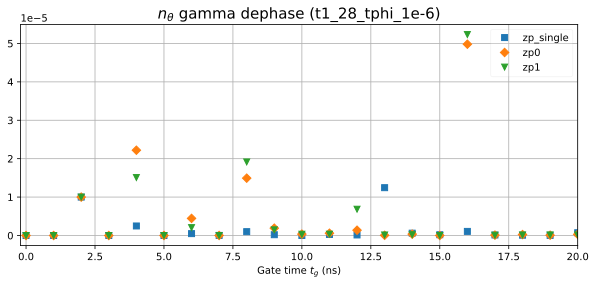

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(zp_single['dephase_50us'], 's', label=r"zp_single")
plt.plot(zp0['dephase'], 'D', label=r'zp0')
plt.plot(zp1['dephase'], 'v', label=r'zp1')
plt.xlim(-0.2,20)
# plt.ylim(0,)
# plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'$n_\theta$ gamma dephase (t1_28_tphi_1e-6)', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

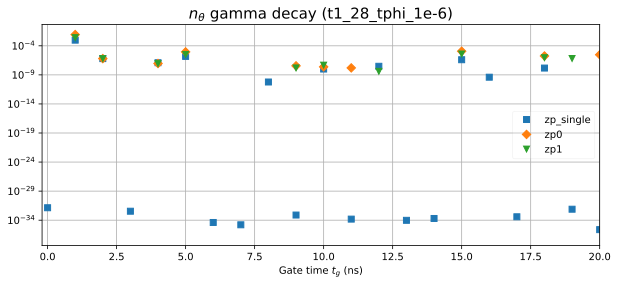

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(zp_single['decay_50us'], 's', label=r"zp_single")
plt.plot(zp0['decay'], 'D', label=r'zp0')
plt.plot(zp1['decay'], 'v', label=r'zp1')
plt.xlim(-0.2,20)
# plt.ylim(0,)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'$n_\theta$ gamma decay (t1_28_tphi_1e-6)', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
folder_1 = 'data/data_xgate_gamma_'
folder_2 = 'theta.txt' if drive_theta else 'phi.txt'
gamma_new = pd.read_csv(folder_1 + folder_2)
gamma_decay_0 = gamma_new[f'decay_{t1_other}us_0'].to_numpy()
gamma_decay_2 = gamma_new[f'decay_{t1_other}us_2'].to_numpy()
gamma_dephase_new = gamma_new['gamma_dephase'].to_numpy()

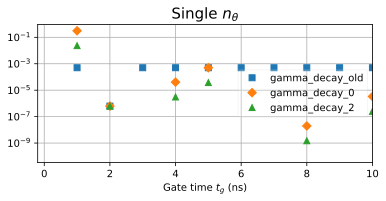

In [ ]:
fig, ax = plt.subplots(figsize=(6,2.5))
plt.plot(np.round(gamma_decay, 10), 's', label=r'gamma_decay_old')
plt.plot(np.round(gamma_decay_0, 10), 'D', label=r'gamma_decay_0')
plt.plot(np.round(gamma_decay_2, 10), '^', label=r'gamma_decay_2')
plt.xlim(-0.2,10)
# plt.ylim(0,)

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'Single $n_\theta$', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent